# Loan Portfolio Risk Copilot — Modeling & Evaluation

Trains and compares multiple candidate PD models on the preprocessed behavioral
dataset, selects the best by a combined discrimination + calibration criterion, and
calibrates it.


## 1. Imports

In [1]:
!pip install lightgbm catboost optuna shap --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 6)

import joblib
import os
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_score, recall_score, f1_score,
    log_loss, brier_score_loss
)

import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import optuna
import shap

RANDOM_STATE = 42

c:\Users\ssanj\miniconda3\envs\conda_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load preprocessed data

In [4]:
model_df = pd.read_parquet('../Data/model_df_behavioral.parquet')
model_df.shape

(1276643, 64)

## 3. Interaction features

In [5]:
model_df['revolutil_fico'] = model_df['revol_util'] * model_df['fico_score_origination']
model_df['dti_loaninc_ratio'] = model_df['dti_log'] * model_df['loan_amount_income_ratio']
model_df['accage_openacc'] = model_df['account_age_years'] * model_df['open_acc']

if 'verification_status_Verified' in model_df.columns:
    model_df['emplen_verif'] = model_df['emp_length'] * model_df['verification_status_Verified']
if 'purpose_debt_consolidation' in model_df.columns:
    model_df['inst_inc_purpose_debtcon'] = (
        model_df['installment_income_ratio'] * model_df['purpose_debt_consolidation']
    )

## 4. Train / validation / test split

In [6]:
X = model_df.drop(columns=['loan_status'])
y = model_df['loan_status']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Default rate -- train: {y_train.mean():.3f}, val: {y_val.mean():.3f}, test: {y_test.mean():.3f}")

Train: (765985, 68), Val: (255329, 68), Test: (255329, 68)
Default rate -- train: 0.202, val: 0.202, test: 0.202


## 5. Evaluation helpers

In [7]:
def ks_statistic(y_true, y_proba):
    """Kolmogorov-Smirnov statistic: max separation between the cumulative
    distributions of predicted scores for defaulters vs. non-defaulters."""
    df = pd.DataFrame({'y': y_true, 'p': y_proba}).sort_values('p')
    df['cum_bad'] = (df['y'] == 1).cumsum() / (df['y'] == 1).sum()
    df['cum_good'] = (df['y'] == 0).cumsum() / (df['y'] == 0).sum()
    return float(np.max(np.abs(df['cum_bad'] - df['cum_good'])))


def evaluate_model(name, y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    auc = roc_auc_score(y_true, y_proba)
    return {
        'model': name,
        'roc_auc': auc,
        'gini': 2 * auc - 1,
        'ks_statistic': ks_statistic(y_true, y_proba),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'log_loss': log_loss(y_true, y_proba),
        'brier_score': brier_score_loss(y_true, y_proba),
    }


results = []
fitted_models = {}
proba_val = {}

## 6. Candidate models

In [8]:
# Logistic Regression -- interpretable baseline. Requires scaled features.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
logreg.fit(X_train_scaled, y_train)

proba_val['Logistic Regression'] = logreg.predict_proba(X_val_scaled)[:, 1]
results.append(evaluate_model('Logistic Regression', y_val, proba_val['Logistic Regression']))
fitted_models['Logistic Regression'] = logreg

In [9]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=50,
    class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)

proba_val['Random Forest'] = rf.predict_proba(X_val)[:, 1]
results.append(evaluate_model('Random Forest', y_val, proba_val['Random Forest']))
fitted_models['Random Forest'] = rf

In [21]:
# XGBoost -- light Optuna search. Given the strongest usual performance on
# tabular credit data, tuning effort is concentrated here rather than spread
# evenly across all candidates; LightGBM/CatBoost below use solid default
# hyperparameters as comparison baselines.
def xgb_objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight': (y_train == 0).sum() / (y_train == 1).sum(),
        'random_state': RANDOM_STATE,
        'eval_metric': 'auc',
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])


study = optuna.create_study(direction='maximize')
study.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

print("Best AUC:", study.best_value)
print("Best params:", study.best_params)

[I 2026-08-16 15:24:56,184] A new study created in memory with name: no-name-c28cab17-62a1-4b57-8053-2c342a8956bf
Best trial: 0. Best value: 0.727874:   3%|▎         | 1/30 [01:02<30:10, 62.42s/it]

[I 2026-08-16 15:25:58,608] Trial 0 finished with value: 0.7278738571115432 and parameters: {'max_depth': 5, 'learning_rate': 0.05538897613822978, 'n_estimators': 423, 'subsample': 0.6096447754861368, 'colsample_bytree': 0.9356240912066448, 'min_child_weight': 9}. Best is trial 0 with value: 0.7278738571115432.


Best trial: 1. Best value: 0.728889:   7%|▋         | 2/30 [01:45<23:55, 51.27s/it]

[I 2026-08-16 15:26:42,074] Trial 1 finished with value: 0.7288894172605146 and parameters: {'max_depth': 6, 'learning_rate': 0.06515439960411912, 'n_estimators': 371, 'subsample': 0.9161700260880061, 'colsample_bytree': 0.9166363279919354, 'min_child_weight': 9}. Best is trial 1 with value: 0.7288894172605146.


Best trial: 1. Best value: 0.728889:  10%|█         | 3/30 [02:35<22:47, 50.64s/it]

...

[I 2026-08-16 15:44:30,508] Trial 27 finished with value: 0.7295816626387698 and parameters: {'max_depth': 6, 'learning_rate': 0.10353714828427299, 'n_estimators': 427, 'subsample': 0.7742072057435744, 'colsample_bytree': 0.6418839363938539, 'min_child_weight': 3}. Best is trial 27 with value: 0.7295816626387698.


Best trial: 27. Best value: 0.729582:  97%|█████████▋| 29/30 [20:21<00:46, 46.62s/it]

[I 2026-08-16 15:45:17,831] Trial 28 finished with value: 0.7247901431209571 and parameters: {'max_depth': 6, 'learning_rate': 0.19668372423799785, 'n_estimators': 431, 'subsample': 0.7627361355170068, 'colsample_bytree': 0.6542264388113787, 'min_child_weight': 3}. Best is trial 27 with value: 0.7295816626387698.


Best trial: 27. Best value: 0.729582: 100%|██████████| 30/30 [21:07<00:00, 42.24s/it]

[I 2026-08-16 15:46:03,526] Trial 29 finished with value: 0.7281707032094601 and parameters: {'max_depth': 4, 'learning_rate': 0.09777968988187101, 'n_estimators': 425, 'subsample': 0.8120565878581181, 'colsample_bytree': 0.6284869319103408, 'min_child_weight': 2}. Best is trial 27 with value: 0.7295816626387698.
Best AUC: 0.7295816626387698
Best params: {'max_depth': 6, 'learning_rate': 0.10353714828427299, 'n_estimators': 427, 'subsample': 0.7742072057435744, 'colsample_bytree': 0.6418839363938539, 'min_child_weight': 3}


In [22]:
# Pre-compute static value once outside the objective function
SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()

def xgb_objective(trial):
    params = {
        'n_estimators': 1000,  # High count; early stopping will truncate training
        'early_stopping_rounds': 30,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        # Regularization parameters
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        
        'scale_pos_weight': SCALE_POS_WEIGHT,
        'tree_method': 'hist',
        'random_state': RANDOM_STATE,
        'eval_metric': 'auc',
    }
    
    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # Model automatically uses best_iteration when early stopping is active
    preds = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, preds)


study = optuna.create_study(direction='maximize')
study.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

print("Best AUC:", study.best_value)
print("Best params:", study.best_params)

[I 2026-08-16 15:46:03,564] A new study created in memory with name: no-name-188be9a8-3dd0-4a55-8be2-923572034e5d
Best trial: 0. Best value: 0.729811:   3%|▎         | 1/30 [01:42<49:18, 102.00s/it]

[I 2026-08-16 15:47:45,568] Trial 0 finished with value: 0.729810776434561 and parameters: {'learning_rate': 0.06387591296181773, 'max_depth': 4, 'subsample': 0.6252603193954395, 'colsample_bytree': 0.9057853643132862, 'min_child_weight': 6, 'reg_alpha': 0.007104094706660498, 'reg_lambda': 0.00018394608085835608}. Best is trial 0 with value: 0.729810776434561.


Best trial: 0. Best value: 0.729811:   7%|▋         | 2/30 [03:24<47:42, 102.22s/it]

[I 2026-08-16 15:49:27,943] Trial 1 finished with value: 0.7271134297964214 and parameters: {'learning_rate': 0.018886846175294406, 'max_depth': 5, 'subsample': 0.6339081443919621, 'colsample_bytree': 0.6816032422820564, 'min_child_weight': 9, 'reg_alpha': 2.742455443240531, 'reg_lambda': 0.00032281258321765853}. Best is trial 0 with value: 0.729810776434561.


Best trial: 0. Best value: 0.729811:  10%|█         | 3/30 [05:03<45:25, 100.94s/it]

...

[I 2026-08-16 16:50:21,012] Trial 27 finished with value: 0.7271578655976576 and parameters: {'learning_rate': 0.028761859972511773, 'max_depth': 4, 'subsample': 0.6618157884353986, 'colsample_bytree': 0.8209242482464043, 'min_child_weight': 9, 'reg_alpha': 2.5086999785583646, 'reg_lambda': 0.10023340006697777}. Best is trial 15 with value: 0.7309276998523091.


Best trial: 15. Best value: 0.730928:  97%|█████████▋| 29/30 [1:06:49<02:13, 133.61s/it]

[I 2026-08-16 16:52:52,662] Trial 28 finished with value: 0.7308843532086062 and parameters: {'learning_rate': 0.05823880526202754, 'max_depth': 5, 'subsample': 0.7739211289920773, 'colsample_bytree': 0.7366949945258934, 'min_child_weight': 8, 'reg_alpha': 2.3821215645495595e-06, 'reg_lambda': 9.835158963239435}. Best is trial 15 with value: 0.7309276998523091.


Best trial: 15. Best value: 0.730928: 100%|██████████| 30/30 [1:09:13<00:00, 138.43s/it]

[I 2026-08-16 16:55:16,603] Trial 29 finished with value: 0.7296783572199653 and parameters: {'learning_rate': 0.05656144443414222, 'max_depth': 4, 'subsample': 0.7803698561184658, 'colsample_bytree': 0.7282778406025712, 'min_child_weight': 6, 'reg_alpha': 1.288118025667248e-06, 'reg_lambda': 5.177811651776048e-05}. Best is trial 15 with value: 0.7309276998523091.
Best AUC: 0.7309276998523091
Best params: {'learning_rate': 0.05458052248135429, 'max_depth': 5, 'subsample': 0.7909349895268198, 'colsample_bytree': 0.7693026120398202, 'min_child_weight': 7, 'reg_alpha': 9.825131514095272, 'reg_lambda': 2.1612986675858538e-07}


In [23]:
best_xgb_params = study.best_params.copy()
best_xgb_params['scale_pos_weight'] = (y_train == 0).sum() / (y_train == 1).sum()
best_xgb_params['random_state'] = RANDOM_STATE

xgb_model = xgb.XGBClassifier(**best_xgb_params)
xgb_model.fit(X_train, y_train)

proba_val['XGBoost'] = xgb_model.predict_proba(X_val)[:, 1]
results.append(evaluate_model('XGBoost', y_val, proba_val['XGBoost']))
fitted_models['XGBoost'] = xgb_model

In [25]:
# 1. Start with the best tuned hyperparameters from Optuna
best_xgb_params = study.best_params.copy()

# 2. Re-attach fixed configuration parameters
best_xgb_params.update({
    'n_estimators': 1000,
    'early_stopping_rounds': 30,
    'scale_pos_weight': SCALE_POS_WEIGHT,
    'tree_method': 'hist',
    'random_state': RANDOM_STATE,
    'eval_metric': 'auc',
})

# 3. Instantiate and train
xgb_model = xgb.XGBClassifier(**best_xgb_params)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 4. Evaluate and store
proba_val['XGBoost'] = xgb_model.predict_proba(X_val)[:, 1]
results.append(evaluate_model('XGBoost', y_val, proba_val['XGBoost']))
fitted_models['XGBoost'] = xgb_model

In [12]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.05,
    class_weight='balanced', random_state=RANDOM_STATE, verbose=-1
)
lgb_model.fit(X_train, y_train)

proba_val['LightGBM'] = lgb_model.predict_proba(X_val)[:, 1]
results.append(evaluate_model('LightGBM', y_val, proba_val['LightGBM']))
fitted_models['LightGBM'] = lgb_model

In [13]:
cat_model = cb.CatBoostClassifier(
    iterations=300, depth=8, learning_rate=0.05,
    auto_class_weights='Balanced', random_state=RANDOM_STATE, verbose=0
)
cat_model.fit(X_train, y_train)

proba_val['CatBoost'] = cat_model.predict_proba(X_val)[:, 1]
results.append(evaluate_model('CatBoost', y_val, proba_val['CatBoost']))
fitted_models['CatBoost'] = cat_model

## 7. Ensemble — stacking classifier

In [14]:
estimators = [
    ('xgb', xgb.XGBClassifier(**best_xgb_params)),
    ('lgb', lgb.LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.05,
                                 class_weight='balanced', random_state=RANDOM_STATE, verbose=-1)),
    ('cat', cb.CatBoostClassifier(iterations=300, depth=8, learning_rate=0.05,
                                    auto_class_weights='Balanced', random_state=RANDOM_STATE, verbose=0)),
]

stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    cv=3, n_jobs=-1
)
stack_clf.fit(X_train, y_train)

proba_val['Stacking Ensemble'] = stack_clf.predict_proba(X_val)[:, 1]
results.append(evaluate_model('Stacking Ensemble', y_val, proba_val['Stacking Ensemble']))
fitted_models['Stacking Ensemble'] = stack_clf

## 8. Model comparison

In [26]:
comparison_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False).reset_index(drop=True)
comparison_df

,model,roc_auc,gini,ks_statistic,precision,recall,f1,log_loss,brier_score
0,XGBoost,0.730928,0.461855,0.336938,0.334337,0.677801,0.447793,0.601054,0.208420
1,Stacking Ensemble,0.729953,0.459906,0.336086,0.574480,0.101626,0.172700,0.447302,0.143029
2,XGBoost,0.729513,0.459027,0.335544,0.336773,0.667203,0.447612,0.595562,0.206117
3,LightGBM,0.726907,0.453814,0.330054,0.328742,0.683033,0.443857,0.607686,0.211325
4,CatBoost,0.724473,0.448945,0.327099,0.327115,0.680843,0.441911,0.609741,0.212152
5,XGBoost,0.719260,0.438520,0.317825,0.322805,0.676813,0.437124,0.614939,0.214293
6,Random Forest,0.715779,0.431559,0.313107,0.324528,0.661487,0.435431,0.608115,0.211111
7,Logistic Regression,0.714385,0.428771,0.311967,0.328098,0.642789,0.434444,0.620503,0.215127


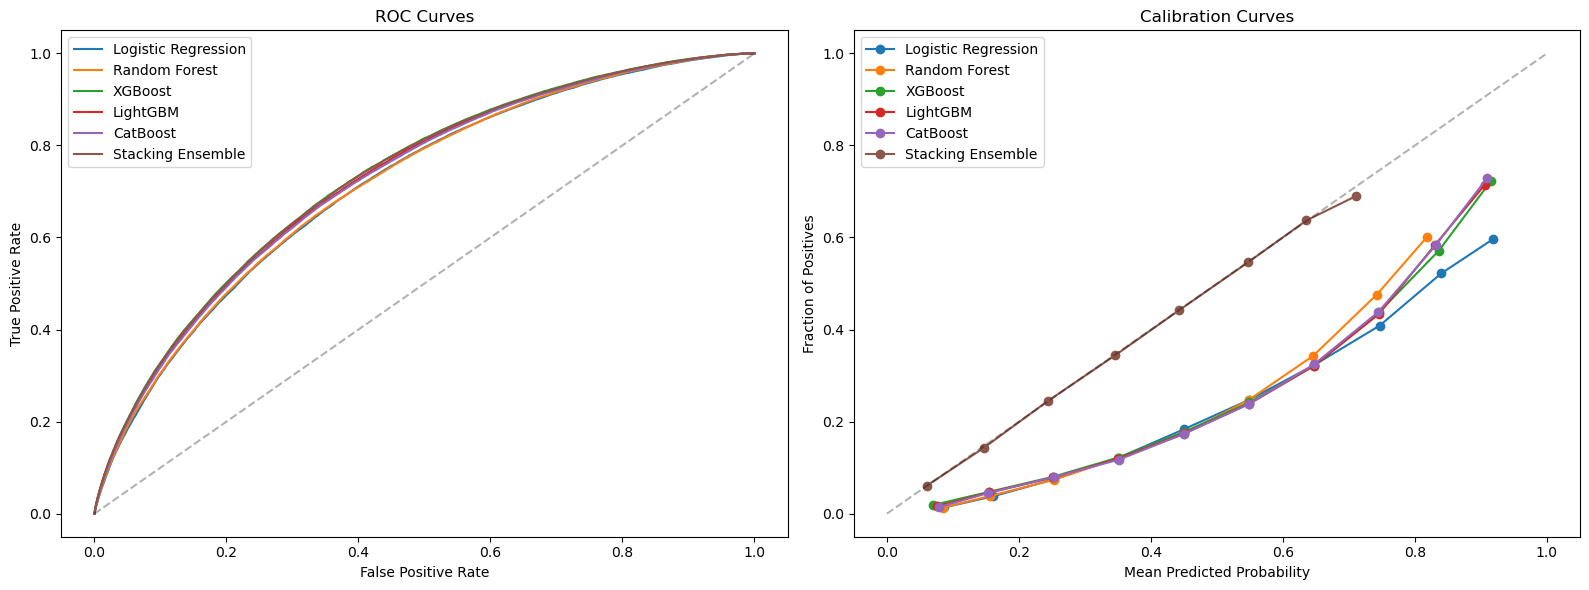

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, proba in proba_val.items():
    fpr, tpr, _ = roc_curve(y_val, proba)
    axes[0].plot(fpr, tpr, label=name)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()

for name, proba in proba_val.items():
    frac_pos, mean_pred = calibration_curve(y_val, proba, n_bins=10)
    axes[1].plot(mean_pred, frac_pos, marker='o', label=name)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].set_title('Calibration Curves')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Model selection

Selection is based on a combined rank of ROC-AUC and Brier score, not AUC
alone -- a model that discriminates well but calibrates poorly produces
unreliable PD values, which corrupts the Expected Loss calculation downstream
(EL = PD x LGD x EAD is only meaningful if PD is calibrated, not just
well-ranked).

In [32]:
comparison_df['auc_rank'] = comparison_df['roc_auc'].rank(ascending=False)
comparison_df['brier_rank'] = comparison_df['brier_score'].rank(ascending=True)
comparison_df['combined_rank'] = (0.8 * comparison_df['auc_rank']) + (0.2 * comparison_df['brier_rank'])

comparison_df_sorted = comparison_df.sort_values('combined_rank')
print(comparison_df_sorted[['model', 'roc_auc', 'gini', 'ks_statistic', 'brier_score', 'combined_rank']])

best_model_name = comparison_df_sorted.iloc[0]['model']
best_model = fitted_models[best_model_name]
print(f"\nSelected model: {best_model_name}")

                 model   roc_auc      gini  ks_statistic  brier_score  \
0              XGBoost  0.730928  0.461855      0.336938     0.208420   
1    Stacking Ensemble  0.729953  0.459906      0.336086     0.143029   
2              XGBoost  0.729513  0.459027      0.335544     0.206117   
3             LightGBM  0.726907  0.453814      0.330054     0.211325   
4             CatBoost  0.724473  0.448945      0.327099     0.212152   
5              XGBoost  0.719260  0.438520      0.317825     0.214293   
6        Random Forest  0.715779  0.431559      0.313107     0.211111   
7  Logistic Regression  0.714385  0.428771      0.311967     0.215127   

   combined_rank  
0            1.4  
1            1.8  
2            2.8  
3            4.2  
4            5.2  
5            6.2  
6            6.4  
7            8.0  

Selected model: XGBoost


## 10. Calibration

In [33]:
calibrated_model = CalibratedClassifierCV(best_model, method='isotonic', cv='prefit')
calibrated_model.fit(X_val, y_val)

proba_test_raw = best_model.predict_proba(X_test)[:, 1]
proba_test_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

print("Before calibration (test set):", evaluate_model('raw', y_test, proba_test_raw))
print("After calibration (test set):", evaluate_model('calibrated', y_test, proba_test_calibrated))

c:\Users\ssanj\miniconda3\envs\conda_env\lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Before calibration (test set): {'model': 'raw', 'roc_auc': np.float64(0.729016261404306), 'gini': np.float64(0.45803252280861195), 'ks_statistic': 0.33247141502197186, 'precision': 0.331812435243011, 'recall': 0.6763611703158303, 'f1': 0.4452111140162361, 'log_loss': 0.6026467317386679, 'brier_score': np.float64(0.20912949498628852)}
After calibration (test set): {'model': 'calibrated', 'roc_auc': np.float64(0.7289163913041641), 'gini': np.float64(0.45783278260832816), 'ks_statistic': 0.33268266423103243, 'precision': 0.5608145806211642, 'recall': 0.11685719821739973, 'f1': 0.19341286639728048, 'log_loss': 0.44791225135614354, 'brier_score': np.float64(0.1432314693380409)}


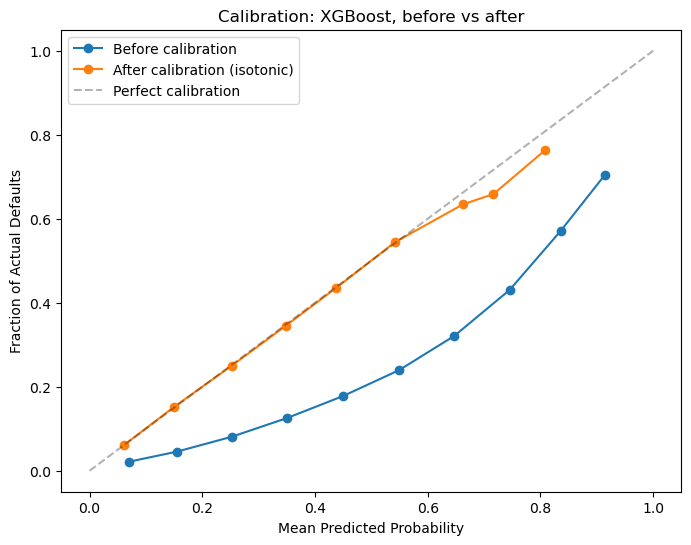

In [34]:
fig, ax = plt.subplots(figsize=(8, 6))
frac_pos_raw, mean_pred_raw = calibration_curve(y_test, proba_test_raw, n_bins=10)
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, proba_test_calibrated, n_bins=10)

ax.plot(mean_pred_raw, frac_pos_raw, marker='o', label='Before calibration')
ax.plot(mean_pred_cal, frac_pos_cal, marker='o', label='After calibration (isotonic)')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Actual Defaults')
ax.set_title(f'Calibration: {best_model_name}, before vs after')
ax.legend()
plt.show()

## 11. Global explainability

Aggregate feature importance across the test set. Per project scope, this
system reports portfolio/segment-level risk, not individual borrower
decisions -- so per-row local explanations aren't part of the output; this
answers "what drives risk across the portfolio," which is the relevant
question here.

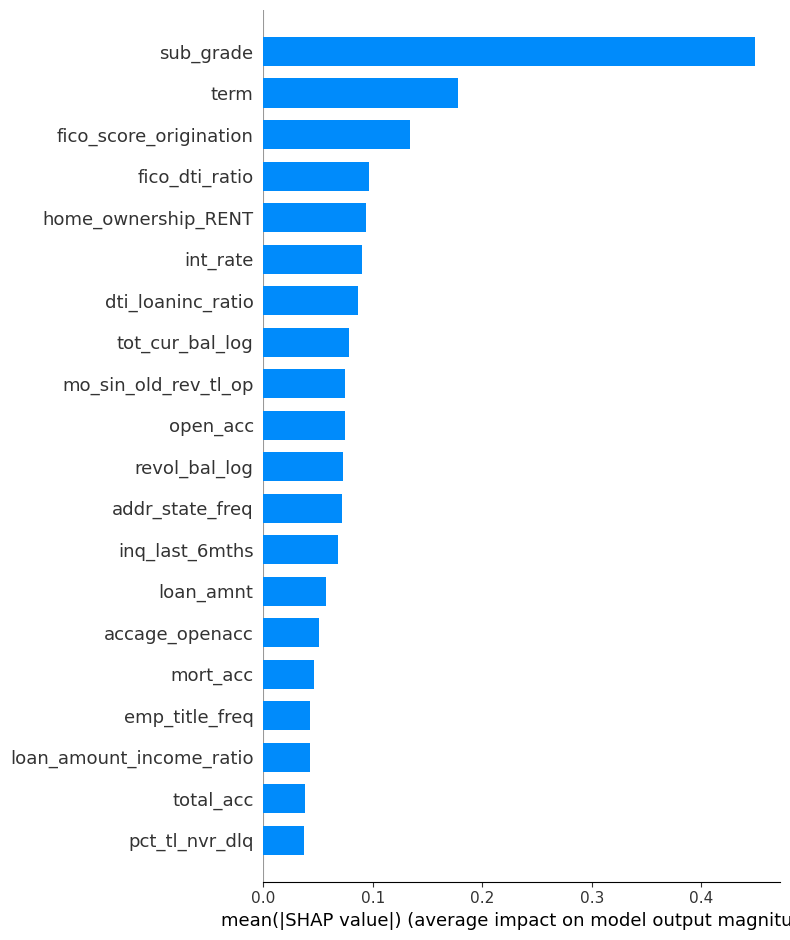

In [35]:
explainer = shap.TreeExplainer(best_model)
sample = X_test.sample(5000, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, plot_type='bar')

## 12. Risk tiers

Buckets calibrated PD into tiers for portfolio-level reporting (e.g. "12% of
retail segment exposure falls in the High Risk tier"), rather than an
approve/reject threshold -- underwriting decisions are out of scope for this
project (see README: portfolio monitoring vs. loan origination).

In [36]:
def assign_risk_tier(pd_value):
    if pd_value < 0.05:
        return 'Low'
    elif pd_value < 0.15:
        return 'Medium'
    elif pd_value < 0.30:
        return 'High'
    return 'Very High'


risk_tiers = pd.Series(proba_test_calibrated).apply(assign_risk_tier)
print(risk_tiers.value_counts(normalize=True).sort_index())

tier_check = pd.DataFrame({'tier': risk_tiers, 'actual_default': y_test.values})
print(tier_check.groupby('tier')['actual_default'].mean())

High         0.365329
Low          0.081746
Medium       0.356101
Very High    0.196824
Name: proportion, dtype: float64
tier
High         0.222494
Low          0.029465
Medium       0.100877
Very High    0.419242
Name: actual_default, dtype: float64


## 13. Save model artifact

In [37]:
joblib.dump(calibrated_model, '../Models/pd_model_calibrated.joblib')
joblib.dump(list(X.columns), '../Models/pd_model_feature_names.joblib')
joblib.dump({'Low': 0.05, 'Medium': 0.15, 'High': 0.30}, '../Models/pd_risk_tier_cutoffs.joblib')

print(f"Saved: {best_model_name} (calibrated), {len(X.columns)} features")
print(f"Test performance: {evaluate_model(best_model_name, y_test, proba_test_calibrated)}")

Saved: XGBoost (calibrated), 68 features
Test performance: {'model': 'XGBoost', 'roc_auc': np.float64(0.7289163913041641), 'gini': np.float64(0.45783278260832816), 'ks_statistic': 0.33268266423103243, 'precision': 0.5608145806211642, 'recall': 0.11685719821739973, 'f1': 0.19341286639728048, 'log_loss': 0.44791225135614354, 'brier_score': np.float64(0.1432314693380409)}


## 4. Inference 

loading the saved model and scoring new loans

In [39]:
## Inference — load the trained behavioral PD model and score loans

import joblib
import pandas as pd

calibrated_model = joblib.load('../Models/pd_model_calibrated.joblib')
feature_names = joblib.load('../Models/pd_model_feature_names.joblib')
tier_cutoffs = joblib.load('../Models/pd_risk_tier_cutoffs.joblib')

def assign_risk_tier(pd_value):
    if pd_value < tier_cutoffs['Low']:
        return 'Low'
    elif pd_value < tier_cutoffs['Medium']:
        return 'Medium'
    elif pd_value < tier_cutoffs['High']:
        return 'High'
    return 'Very High'

In [41]:
def predict_pd(df: pd.DataFrame) -> pd.DataFrame:
    """
    Scores loans with the calibrated behavioral PD model.
    `df` must already be feature-engineered per 01_feature_engineering.ipynb.
    """
    missing = [f for f in feature_names if f not in df.columns]
    for f in missing:
        df[f] = 0
    if missing:
        print(f"Warning -- filled missing features with 0: {missing}")

    X = df[feature_names]

    df = df.copy()
    df['predicted_pd'] = calibrated_model.predict_proba(X)[:, 1]
    df['risk_tier'] = df['predicted_pd'].apply(assign_risk_tier)
    return df

In [42]:
## Example invocation — single loan

import pandas as pd

# One hypothetical borrower/loan, already feature-engineered the same way
# 01_feature_engineering.ipynb would produce it (this is what a single row
# looks like right before it hits the model -- e.g. what the Data Agent would
# hand off after querying + transforming one loan record).
example_loan = {
    # Origination-side
    'loan_amnt': 15000, 'int_rate': 11.5, 'term': 0, 'installment': 494.8,
    'sub_grade': 2.3,  # B3
    'emp_length': 5, 'annual_inc_log': 11.0821, 'dti_log': 2.9704,
    'open_acc': 10, 'total_acc': 22, 'pub_rec': 0, 'delinq_2yrs': 0,
    'acc_now_delinq': 0, 'num_tl_90g_dpd_24m': 0, 'mo_sin_old_rev_tl_op': 120,
    'mort_acc': 1, 'pct_tl_nvr_dlq': 95.0, 'pub_rec_bankruptcies': 0,
    'mths_since_last_delinq': 999, 'mths_since_last_record': 999,  # sentinel: never
    'revol_util': 40.0, 'revol_bal_log': 8.9873, 'tot_coll_amt_log': 0.0,
    'tot_cur_bal_log': 10.7144, 'inq_last_6mths': 1,
    'fico_score_origination': 702, 'fico_dti_ratio': 36.0,
    'account_age_years': 8.5, 'emp_title_freq': 350, 'addr_state_freq': 0.045,

    # Behavioral
    'on_payment_plan': 0, 'entered_hardship': 0, 'distress_combo': 0,

    # Engineered ratios/flags
    'credit_card_util_pct': 0.1778, 'installment_income_ratio': 0.007612,
    'loan_amount_income_ratio': 0.2308, 'delinq_flag': 0, 'bankruptcy_flag': 0,
    'historical_delinquency_rate': 0.0,

    # One-hot (baseline categories dropped: verification 'Not Verified',
    # home_ownership 'MORTGAGE', purpose 'car' -- all zero here means this
    # loan IS a MORTGAGE-owner with 'car' purpose unless flagged otherwise)
    'verification_status_Source Verified': 1, 'verification_status_Verified': 0,
    'home_ownership_OTHER': 0, 'home_ownership_OWN': 0, 'home_ownership_RENT': 0,
    'purpose_debt_consolidation': 1,  # all other purpose_* dummies = 0

    # Missing-value flags
    'inq_last_6mths_missing': 0, 'mths_since_last_delinq_missing': 0,
    'mths_since_last_record_missing': 0, 'revol_util_missing': 0,
    'num_tl_90g_dpd_24m_missing': 0, 'emp_length_missing': 0,

    # Interaction terms
    'revolutil_fico': 28080.0, 'dti_loaninc_ratio': 0.6854,
    'accage_openacc': 85.0, 'emplen_verif': 0, 'inst_inc_purpose_debtcon': 0.007612,
}

single_loan_df = pd.DataFrame([example_loan])
scored = predict_pd(single_loan_df)

print(f"Predicted PD: {scored['predicted_pd'].iloc[0]:.4f}")
print(f"Risk tier:    {scored['risk_tier'].iloc[0]}")

Warning -- filled missing features with 0: ['purpose_credit_card', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding']
Predicted PD: 0.1272
Risk tier:    Medium
